c

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import nltk
nltk.download('punkt')#word tokenization
nltk.download('stopwords')#Lists of stop words
nltk.download('wordnet')#Lexical database used for lemmatization
nltk.download('averaged_perceptron_tagger')#Part-of-speech (POS) tagging
nltk.download('omw-1.4')
nltk.download('punkt_tab') 
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import string
import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package punkt to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## DATASET
20 Newsgroups — 18,846 documents, 20 categories

In [2]:
# 8 well-chosen categories 
categories = [
    'comp.graphics', 'comp.sys.mac.hardware',
    'rec.autos', 'rec.sport.hockey',
    'sci.med', 'sci.space',
    'talk.politics.guns', 'talk.religion.misc'
]
print("Loading 20 Newsgroups dataset...")
train_data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),  # remove metadata 
    random_state=42
)

test_data = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)



Loading 20 Newsgroups dataset...


In [3]:
print(f"Training samples: {len(train_data.data)}")
print(f"Test samples:     {len(test_data.data)}")
print(f"Categories:       {train_data.target_names}")


Training samples: 4466
Test samples:     2974
Categories:       ['comp.graphics', 'comp.sys.mac.hardware', 'rec.autos', 'rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.guns', 'talk.religion.misc']


In [4]:
train_data.data

["\n\n\n\nAccording to _The Complete Guide To Specialty Cars_, 7th Edition, from\nCrown Publishing, it's the VW Kubelwagen (w/ 2 dots over the 'u').\nThe company is:\n\n   Wolfkam\n   P.O. Box 1608, Vika\n   0119 Oslo 1, Norway\n\n   011-47-30-26601 voice line\n   011-47-2-166138 FAX line\n\n\nAn excerpt from the blurb:\n\n   ...This fine Kubel clone from Wolfkam is a very close copy of\n   the original, and offers the same all-weather and cross-country\n   capabilities as its WWII forebears.  The robust fiberglass body\n   kit is very complete, and includes all the hardware you will\n   need, except for your own VW donor car.  The phone number [...]\n   is the entire AT&T dialing sequence; call and ask for Karl\n   Torum, or send $5 cash or _International Money Order_\n   for a complete literature package.\n\n\nGeorge.\n\nP.S., I'd be happy to share what info I have on other kit cars and\n      kit car manufacturers.",
 '\nThere is no law prohibiting having biological weapons or nerve

In [5]:
np.unique(train_data.target)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [6]:
train_data.target

array([2, 6, 0, ..., 0, 3, 4], shape=(4466,))

## EXPLORATORY DATA ANALYSIS

In [7]:
# class distribution
train_df=pd.DataFrame( {
                          "text":train_data.data,
                           "label":train_data.target,
                           "category":[train_data.target_names[i] for i in train_data.target]
                          
                      })

In [8]:
print("\n--- Class Distribution ---")
print(train_df['category'].value_counts())


--- Class Distribution ---
category
rec.sport.hockey         600
rec.autos                594
sci.med                  594
sci.space                593
comp.graphics            584
comp.sys.mac.hardware    578
talk.politics.guns       546
talk.religion.misc       377
Name: count, dtype: int64


In [9]:
train_df

,text,label,category
0,\n\n\n\nAccording to _The Complete Guide To Sp...,2,rec.autos
1,\nThere is no law prohibiting having biologica...,6,talk.politics.guns
2,"Ok, lets say youve got a grid of hexagons\n\nt...",0,comp.graphics
3,\n\n\n\n\nWhen I was at the Texas Star Party a...,5,sci.space
4,"\nCS ""tear-gas"" was used in Vietnam because it...",6,talk.politics.guns
...,...,...,...
4461,"on wednesday morning, another driver decided t...",2,rec.autos
4462,I was reading Popular Science this morning and...,5,sci.space
4463,"Dear Reader,\n\n\nI'am searching for an implem...",0,comp.graphics
4464,\n As a person who has rarely even SEEN Do...,3,rec.sport.hockey


In [10]:
train_df["text"][0]

"\n\n\n\nAccording to _The Complete Guide To Specialty Cars_, 7th Edition, from\nCrown Publishing, it's the VW Kubelwagen (w/ 2 dots over the 'u').\nThe company is:\n\n   Wolfkam\n   P.O. Box 1608, Vika\n   0119 Oslo 1, Norway\n\n   011-47-30-26601 voice line\n   011-47-2-166138 FAX line\n\n\nAn excerpt from the blurb:\n\n   ...This fine Kubel clone from Wolfkam is a very close copy of\n   the original, and offers the same all-weather and cross-country\n   capabilities as its WWII forebears.  The robust fiberglass body\n   kit is very complete, and includes all the hardware you will\n   need, except for your own VW donor car.  The phone number [...]\n   is the entire AT&T dialing sequence; call and ask for Karl\n   Torum, or send $5 cash or _International Money Order_\n   for a complete literature package.\n\n\nGeorge.\n\nP.S., I'd be happy to share what info I have on other kit cars and\n      kit car manufacturers."

In [11]:
# Document length distribution
train_df["char_length"]=train_df["text"].apply(len)
train_df["word_count"]=train_df['text'].apply(lambda x: len(x.split()))

In [12]:
train_df

,text,label,category,char_length,word_count
0,\n\n\n\nAccording to _The Complete Guide To Sp...,2,rec.autos,898,143
1,\nThere is no law prohibiting having biologica...,6,talk.politics.guns,605,100
2,"Ok, lets say youve got a grid of hexagons\n\nt...",0,comp.graphics,694,115
3,\n\n\n\n\nWhen I was at the Texas Star Party a...,5,sci.space,551,96
4,"\nCS ""tear-gas"" was used in Vietnam because it...",6,talk.politics.guns,222,40
...,...,...,...,...,...
4461,"on wednesday morning, another driver decided t...",2,rec.autos,648,115
4462,I was reading Popular Science this morning and...,5,sci.space,896,164
4463,"Dear Reader,\n\n\nI'am searching for an implem...",0,comp.graphics,436,75
4464,\n As a person who has rarely even SEEN Do...,3,rec.sport.hockey,688,130


In [13]:
print(f"\nAverage document length: {train_df['word_count'].mean():.1f} words")
print(f"Median document length:  {train_df['word_count'].median():.1f} words")
print(f"Max document length:     {train_df['word_count'].max()} words")
print(f"Min document length:     {train_df['word_count'].min()} words")



Average document length: 175.8 words
Median document length:  79.0 words
Max document length:     11251 words
Min document length:     0 words


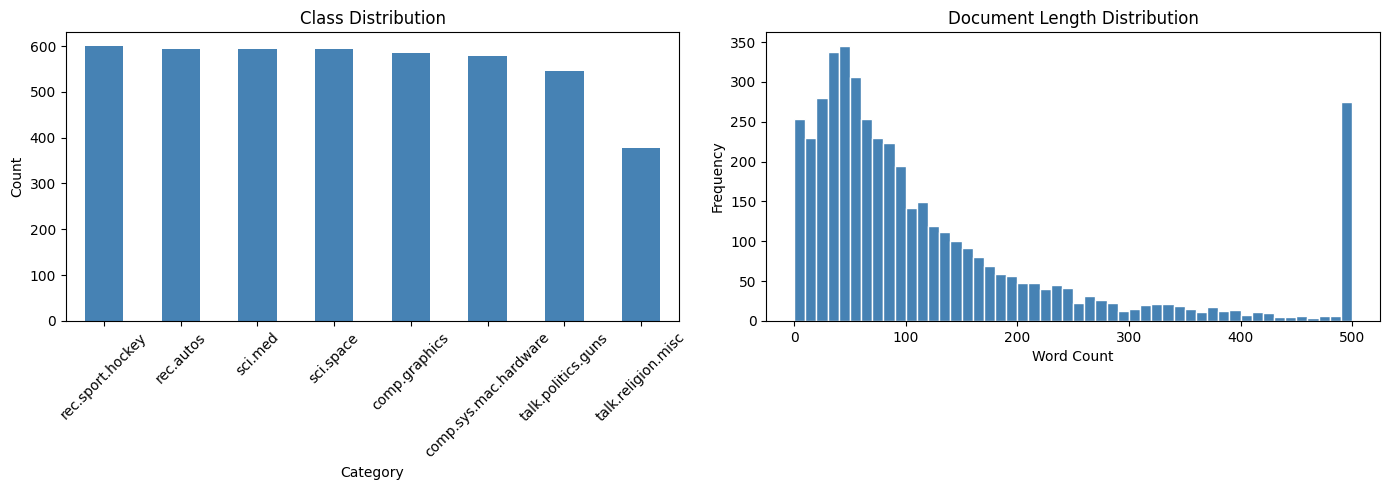

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#Class Distribution
train_df['category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
#Document Length Distribution
axes[1].hist(train_df['word_count'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Document Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig("/home/hossamhamdy/AI_Portfolio/project_05_Classic_NLP_text_classification/results/01_eda.png", dpi=150, bbox_inches='tight')
plt.show()

## PREPROCESSING PIPELINE

In [16]:
class TextPreprocessor:
    def __init__(self,use_stemming=False,
                 use_lemmatization=True,remove_stopwords=True,
                 min_word_length=2):
        self.use_stemming = use_stemming
        self.use_lemmatization = use_lemmatization
        self.remove_stopwords = remove_stopwords
        self.min_word_length = min_word_length
        
        self.stemmer=PorterStemmer()
        self.lemmatizer=WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

        # CRITICAL: preserve negations — "not" is a stop word by default
        # Removing it would turn "not good" into "good"
        self.stop_words.discard('not')
        self.stop_words.discard('no')
        self.stop_words.discard('nor')
     
    def clean(self,text):
        # Remove URLs (keep as token)
        text=re.sub(r'http\S+|www\S+','TOKENURL',text)
        # Remove emails (keep as token)
        text = re.sub(r'\S+@\S+', 'TOKENEMAIL', text) 
        # Remove numbers (keep as token)  
        text=re.sub(r'\d+','TOKENNUM',text)
        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        # Lowercase
        text = text.lower()
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    def tokenize(self,text):
        return word_tokenize(text)
    def normalize(self,tokens):
        if self.use_lemmatization:
            return [self.lemmatizer.lemmatize(t) for t in tokens]
        elif self.use_stemming:
            return [self.stemmer.stem(t) for t in tokens]
        return tokens
    def filter(self,tokens):
        # Remove stop words and short tokens
        filtered = []
        for token in tokens:
            if len(token) < self.min_word_length:
                continue
            if self.remove_stopwords and token in self.stop_words:
                continue
            filtered.append(token)
        return filtered
    
    def process(self, text):
        #Full pipeline
        text   = self.clean(text)
        tokens = self.tokenize(text)
        tokens = self.normalize(tokens)
        tokens = self.filter(tokens)
        return ' '.join(tokens)

    def fit_transform(self, texts):
        #Process a list of texts
        return [self.process(t) for t in texts]
        

In [17]:
print("\nPreprocessing training data...")
preprocessor = TextPreprocessor()
X_train_processed = preprocessor.fit_transform(train_data.data)
X_test_processed = preprocessor.fit_transform(test_data.data)



Preprocessing training data...


In [ ]:
# Show before/after
print("\n--- Preprocessing Example ---")
print("BEFORE:", train_data.data[0][0:300])
print("\nAFTER:", X_train_processed[0][0:300])


--- Preprocessing Example ---
BEFORE: 



According to _The Complete Guide To Specialty Cars_, 7th Edition, from
Crown Publishing, it's the VW Kubelwagen (w/ 2 dots over the 'u').
The company is:

   Wolfkam
   P.O. Box 1608, Vika
   0119 Oslo 1, Norway

   011-47-30-26601 voice line
   011-47-2-166138 FAX line


An excerpt from the blu

AFTER: according complete guide specialty car tokennumth edition crown publishing vw kubelwagen tokennum dot company wolfkam po box tokennum vika tokennum oslo tokennum norway tokennumtokennumtokennumtokennum voice line tokennumtokennumtokennumtokennum fax line excerpt blurb fine kubel clone wolfkam close 


In [18]:
X_train_processed

['according complete guide specialty car tokennumth edition crown publishing vw kubelwagen tokennum dot company wolfkam po box tokennum vika tokennum oslo tokennum norway tokennumtokennumtokennumtokennum voice line tokennumtokennumtokennumtokennum fax line excerpt blurb fine kubel clone wolfkam close copy original offer allweather crosscountry capability wwii forebear robust fiberglass body kit complete includes hardware need except vw donor car phone number entire att dialing sequence call ask karl torum send tokennum cash international money order complete literature package george id happy share info kit car kit car manufacturer',
 'no law prohibiting biological weapon nerve gas hisher property even walking government property item ipso facto one right weapon mass destruction hell patent office ha patent manufacture nerve gas anyone obtain simply sending tokennumtokennum patent office washington dc po box tokennum patent verboten english citizen patent office doesnt surprise based m

## TF-IDF -->vectorization

In [ ]:
tfidf = TfidfVectorizer(
    max_features=50000, #most important words in the vocab     
    max_df=0.95,  # if  aword appear more than 0.95% stop it
    ngram_range=(1, 2),   #both unigrams and bigrams
    sublinear_tf=True  #Changes the local term frequency formula from raw count to a logarithmic scale
)
X_train_tfidf = tfidf.fit_transform(X_train_processed)
X_test_tfidf = tfidf.transform(X_test_processed)

In [ ]:
print(f"\nTF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Matrix sparsity: {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}")

# Top TF-IDF terms per category
print("\n--- Top TF-IDF Terms Per Category ---")
feature_names = np.array(tfidf.get_feature_names_out())
for cat_id, cat_name in enumerate(train_data.target_names):
    cat_docs = X_train_tfidf[train_data.target == cat_id]
    mean_tfidf = np.asarray(cat_docs.mean(axis=0)).flatten()
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    top_terms = feature_names[top_indices]
    print(f"{cat_name}: {', '.join(top_terms)}")


TF-IDF matrix shape: (4466, 50000)
Vocabulary size: 50000
Matrix sparsity: 0.9983

--- Top TF-IDF Terms Per Category ---
comp.graphics: file, tokennum, graphic, thanks, image, program, know, format, tokennumd, anyone
comp.sys.mac.hardware: tokennum, mac, apple, drive, problem, not, thanks, one, card, tokennumtokennum
rec.autos: car, tokennum, wa, not, like, would, tokennumtokennum, engine, one, get
rec.sport.hockey: game, team, tokennum, wa, hockey, player, play, playoff, season, nhl
sci.med: not, tokenemail, gordon, gordon bank, tokennum, bank, skepticism, bank ntokennumjxp, skepticism chastity, chastity intellect
sci.space: space, tokennum, wa, would, not, orbit, nasa, launch, like, one
talk.politics.guns: gun, not, wa, would, tokennum, people, weapon, no, law, right
talk.religion.misc: god, not, christian, jesus, wa, no, people, bible, one, tokennum


## BASELINE CLASSIFIERS

In [ ]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM': LinearSVC(C=1.0, max_iter=2000, random_state=42)
}

In [ ]:
results = {}
print("\n--- Training Classifiers ---")

for name, clf in classifiers.items():
    clf.fit(X_train_tfidf, train_data.target)
    train_score = clf.score(X_train_tfidf, train_data.target)
    test_score = clf.score(X_test_tfidf, test_data.target)
    results[name] = {'train': train_score, 'test': test_score}
    print(f"{name}: Train={train_score:.4f} | Test={test_score:.4f}")


--- Training Classifiers ---
Logistic Regression: Train=0.9606 | Test=0.8171
Naive Bayes: Train=0.9615 | Test=0.8178
Linear SVM: Train=0.9722 | Test=0.8218


In [ ]:
# Best model detailed report
best_clf = classifiers['Linear SVM']
y_pred = best_clf.predict(X_test_tfidf)

print("\n--- Linear SVM Detailed Report ---")
print(classification_report(
    test_data.target, y_pred,
    target_names=test_data.target_names
))


--- Linear SVM Detailed Report ---
                       precision    recall  f1-score   support

        comp.graphics       0.83      0.84      0.84       389
comp.sys.mac.hardware       0.87      0.84      0.85       385
            rec.autos       0.72      0.89      0.79       396
     rec.sport.hockey       0.94      0.90      0.92       399
              sci.med       0.87      0.79      0.83       396
            sci.space       0.81      0.79      0.80       394
   talk.politics.guns       0.79      0.77      0.78       364
   talk.religion.misc       0.75      0.69      0.72       251

             accuracy                           0.82      2974
            macro avg       0.82      0.82      0.82      2974
         weighted avg       0.83      0.82      0.82      2974



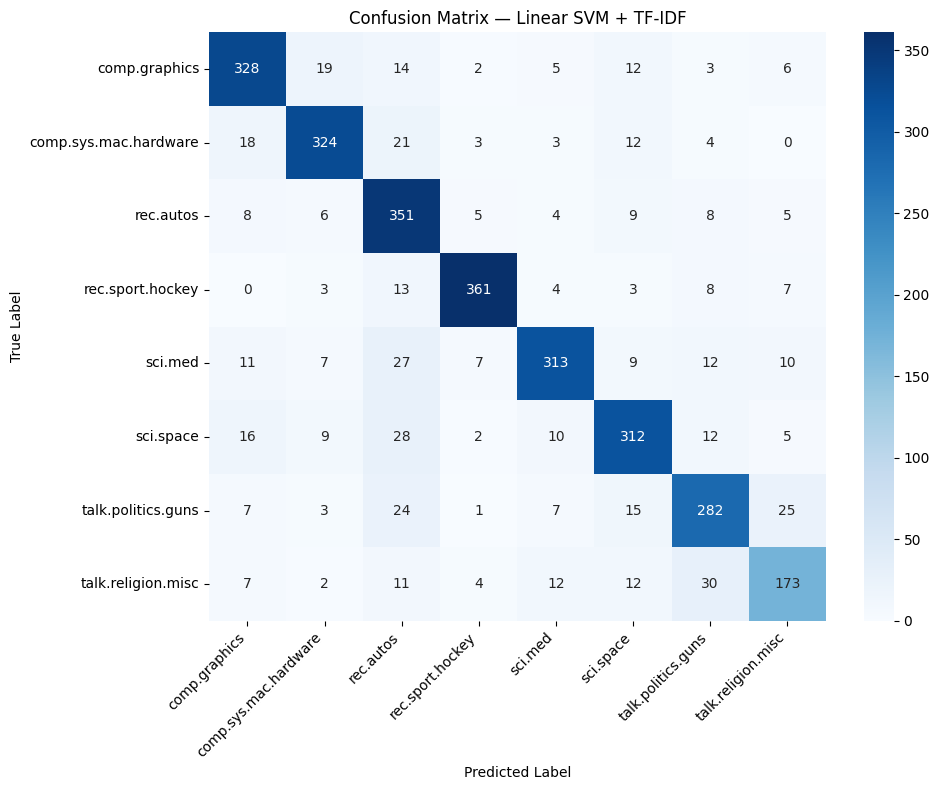

In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(test_data.target, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.target_names,
            yticklabels=test_data.target_names, ax=ax)
ax.set_title('Confusion Matrix — Linear SVM + TF-IDF')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## DOCUMENT WHERE TF-IDF FAILS

In [ ]:
print("\n--- Where TF-IDF Fails ---")

# Find misclassified examples
misclassified_idx = np.where(y_pred != test_data.target)[0]
print(f"\nTotal misclassifications: {len(misclassified_idx)}")

# Show semantic similarity failure
similar_pairs = [
    ("The car engine produces excellent horsepower",
     "The automobile motor generates outstanding power"),
    ("Space exploration is fascinating",
     "Astronauts traveling to the cosmos is amazing")
]


--- Where TF-IDF Fails ---

Total misclassifications: 530


In [ ]:
print("\n--- Semantic Gap Demonstration ---")
for s1, s2 in similar_pairs:
    v1 = tfidf.transform([preprocessor.process(s1)])
    v2 = tfidf.transform([preprocessor.process(s2)])

    # Cosine similarity
    from sklearn.metrics.pairwise import cosine_similarity
    sim = cosine_similarity(v1, v2)[0][0]
    print(f"\nS1: '{s1}'")
    print(f"S2: '{s2}'")
    print(f"TF-IDF Cosine Similarity: {sim:.4f}  ← should be high, is near 0")


--- Semantic Gap Demonstration ---

S1: 'The car engine produces excellent horsepower'
S2: 'The automobile motor generates outstanding power'
TF-IDF Cosine Similarity: 0.0000  ← should be high, is near 0

S1: 'Space exploration is fascinating'
S2: 'Astronauts traveling to the cosmos is amazing'
TF-IDF Cosine Similarity: 0.0000  ← should be high, is near 0


## Summary

In [ ]:
print("\n" + "="*60)
print("DAY 1 RESULTS SUMMARY")
print("="*60)
print(f"Dataset: 20 Newsgroups ({len(train_data.data)} train, {len(test_data.data)} test)")
print(f"Categories: {len(categories)}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print()
for name, scores in results.items():
    gap = scores['train'] - scores['test']
    print(f"{name}:")
    print(f"  Train: {scores['train']:.4f} | Test: {scores['test']:.4f} | Gap: {gap:.4f}")
print()
print("Best model: Linear SVM")
print("Key finding: TF-IDF fails on semantically similar but lexically different text")
print("This gap motivates Word2Vec ")


DAY 1 RESULTS SUMMARY
Dataset: 20 Newsgroups (4466 train, 2974 test)
Categories: 8
Vocabulary size: 50000

Logistic Regression:
  Train: 0.9606 | Test: 0.8171 | Gap: 0.1435
Naive Bayes:
  Train: 0.9615 | Test: 0.8178 | Gap: 0.1437
Linear SVM:
  Train: 0.9722 | Test: 0.8218 | Gap: 0.1504

Best model: Linear SVM
Key finding: TF-IDF fails on semantically similar but lexically different text
This gap motivates Word2Vec 
